# Full model fit and phenotype characterization

This notebook fits the final MMER-XGBoost specification to eligible free-living meals, then characterizes participant phenotype coordinates derived from the random-effect covariance. Standardized meals are excluded from fitting and used for subsequent association analyses.

## Notebook flow

1. Fit the final model and summarize its variance components and model fit.
2. Decompose the full random-effect covariance, calculate BLUP-based PC scores, and examine macronutrient-slope covariance conditional on intercepts.
3. Relate PC scores to CGM summaries, demographics, and adiposity measures.
4. Test associations with standardized-meal responses, including nested-model and extreme-quartile comparisons.
5. Evaluate cross-validated prediction of PC scores from demographics and adiposity against permutation benchmarks.

## Outputs

CSV files written to `Results/`:

| File | Contents |
| --- | --- |
| `adiposity_block_results.csv` | Incremental variance explained by adiposity beyond age and sex. |
| `adiposity_model_coefficients.csv` | Coefficients from the demographic and adiposity regression models. |
| `PC_CGM_metrics_partial_correlations.csv` | PC–CGM partial correlations adjusted for age, sex, and BMI, with confidence intervals and FDR-adjusted values. |
| `PC_standardized_meal_outcomes_correlations.csv` | PC–standardized-meal outcome correlations and multiple-testing results. |
| `PC_standardized_meal_outcomes_nested_model_comparisons.csv` | Added explanatory value of each PC beyond demographic and CGM covariates. |
| `PC_extreme_quartiles_comparison.csv` | Standardized-meal outcome comparisons between the lowest and highest PC-score quartiles. |
| `oos_adiposity_PC_r2_vs_permutations.csv` | Cross-validated PC-score prediction from demographics/adiposity and permutation benchmarks. |

Phenotype scatter, loading, and characterization figures are saved to `Figures/`.

## 1. Setup

Resolve project paths, import the modeling utilities, and load the common prepared meal-level dataset.

In [1]:
from pathlib import Path
import sys

# Find the project when launched from its root, Code/, or a notebook subfolder.
for PROJECT_ROOT in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    CODE_DIR = PROJECT_ROOT / "Code"
    if (CODE_DIR / "data_paths.py").is_file():
        break
else:
    raise FileNotFoundError("Open this notebook from within the project directory.")

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

# Shared defaults; override individual paths here if needed.
from data_paths import DATA_DIR, METADATA_PATH, MEAL_DATA_PATH, CGM_METRICS_PATH
FIGURES_DIR = PROJECT_ROOT / "Figures"
RESULTS_DIR = PROJECT_ROOT / "Results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
import logging
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

import xgboost as xgb
from mmer import MixedEffectEstimator
from sklearn.model_selection import BaseCrossValidator, GroupKFold
from tqdm import tqdm

In [3]:
from utils import (
    build_design_mats,
    load_and_prepare_data,
    make_xgb,
)

In [4]:
meta_data, data, id_to_subject_key, clusters = load_and_prepare_data(
    METADATA_PATH,
    MEAL_DATA_PATH,
)

print(f"Prepared {len(data):,} meals from {data['subject_key'].nunique():,} participants.")

data shape : (54987, 133)
Prepared 54,987 meals from 992 participants.


## 2. Final MMER-XGBoost fit

In [5]:
import xgboost as xgb
from mmer import MixedEffectEstimator
groups = clusters.to_numpy()

results_list = []

prediction_metrics = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC",]

print("Dataset size:", data.shape)

print("Build the design matrix....")
X_train, _, Z_train, _, y_train, _, clusters_train, _, cluster_mapping, info_, _, validation_dataframe = \
    build_design_mats(
        data,
        full_train=True,
        target_outcome=prediction_metrics,
        apply_mundlak=False,
        use_interactions=[False],
        population_z_scoring_features=True,
        remove_std_meals_from_training=True,
        remove_features=["demographics"],
        random_slopes=["carb_eaten", "fat_eaten", "protein_eaten", "fiber_eaten"],
        population_z_scoring_outcome=True,
    )

print("Train the model...")
xgb_fe = make_xgb(njobs=12)

final_model = MixedEffectEstimator(xgb_fe, max_iter=50, slq_steps=40, tol=1e-07, n_jobs=4)

groups_train_mmer = clusters_train.to_numpy().reshape(-1, 1)
y_train_mmer = np.asarray(y_train)
if y_train_mmer.ndim == 1:
    y_train_mmer = y_train_mmer.reshape(-1, 1)

final_model_result = final_model.fit(X_train, y_train_mmer, groups_train_mmer,random_slopes=([0, 1, 2, 3],))

Dataset size: (54987, 133)
Build the design matrix....
Train the model...


Finished: no further improvement!:  66%|██████▌   | 33/50 06:56         


In [6]:
print(final_model_result.summary())


Mixed Model Summary
  FE Model:             XGBRegressor
  Iterations:           34
  Converged:            Yes (Early Stopped)
  Log-Likelihood:       -117685.718
  FE DF:                0 (Agnostic ML Model)
  AIC:                  235811.435
  BIC:                  237753.814
  Outputs (n_responses):4
  Groups (n_groups):    1
------------------------------------------------------------
  Residual Variances (R)
      Response       Variance
      1                0.2380
      2                0.3715
      3                0.3175
      4                0.3174
------------------------------------------------------------
  Random Effects Variances (G)
      Group    Response   Effect              Variance
      1        1          Intercept             0.0956
      1        1          Slope 1               0.0386
      1        1          Slope 2               0.0055
      1        1          Slope 3               0.0073
      1        1          Slope 4               0.0069
      1  

In [7]:
final_model_result.icc()

{'Group_0': array([0.2864866 , 0.10672175, 0.24501717, 0.28009598])}

In [8]:
final_model_result.pseudo_r2(X_train, y_train, groups_train_mmer)

{'marginal': array([0.56515429, 0.5498905 , 0.4243378 , 0.50272647]),
 'conditional': array([0.69880242, 0.5960962 , 0.56871975, 0.65626805])}

## 3. Covariance decomposition and participant PC scores

The random-effect covariance is decomposed once, and the resulting basis is reused throughout the remainder of this notebook.

In [9]:
def covariance_pca(G, labels=None, blups=None, cluster_mapping=None, clip_negative=True):
    G = np.asarray(G, float)
    G = 0.5 * (G + G.T)  # symmetrize

    eigvals, eigvecs = np.linalg.eigh(G)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # When clip_negative is enabled, normalize by the non-negative eigenvalues,
    # matching bootstrap post-processing and excluding negative variance estimates.
    var = np.clip(eigvals, 0, None) if clip_negative else eigvals
    variance_explained = pd.Series(
        var / var.sum(),
        index=[f"PC{i+1}" for i in range(len(eigvals))],
        name="variance_explained",
    )

    if labels is None:
        labels = [f"V{i+1}" for i in range(G.shape[0])]

    loadings = pd.DataFrame(eigvecs, index=labels, columns=variance_explained.index)

    print("Variance explained:")
    print((100 * variance_explained).round(2).astype(str) + "%")

    scores = None
    if blups is not None:
        X = blups.values if isinstance(blups, pd.DataFrame) else np.asarray(blups)
        X = X - X.mean(axis=0)
        scores = pd.DataFrame(
            X @ eigvecs,
            index=blups.index if isinstance(blups, pd.DataFrame) else None,
            columns=variance_explained.index,
        )
        if cluster_mapping is not None:
            scores = scores.reset_index().rename(columns={"Group_0": "cluster"})
            scores = scores.merge(cluster_mapping, on="cluster", how="inner")

    return loadings, variance_explained, scores

In [10]:
# Get BLUPs
blups = final_model_result.blups(
    X=X_train,
    y=y_train_mmer,
    groups=groups_train_mmer,
    group_idx=0,
)
effect_names = ["Intercept", "Carb", "Fat", "Protein", "Fiber"]
outcome_names = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC",]
labels = [f"{y}|{e}" for y in outcome_names for e in effect_names]

blups.columns = labels
G_full = final_model_result.G[0]
# PCA
loadings, var_exp, scores = covariance_pca(
    G=G_full,
    labels=labels,
    blups=blups,
    cluster_mapping = cluster_mapping
)

df_scores = pd.merge(meta_data, scores[["subject_key", "PC1", "PC2", "PC3"]], on="subject_key")

Variance explained:
PC1     69.32%
PC2     11.79%
PC3      5.04%
PC4      4.66%
PC5      3.36%
PC6      1.69%
PC7      0.86%
PC8      0.66%
PC9      0.53%
PC10     0.44%
PC11      0.4%
PC12     0.37%
PC13     0.26%
PC14     0.22%
PC15     0.12%
PC16      0.1%
PC17     0.08%
PC18     0.07%
PC19     0.02%
PC20      0.0%
Name: variance_explained, dtype: object


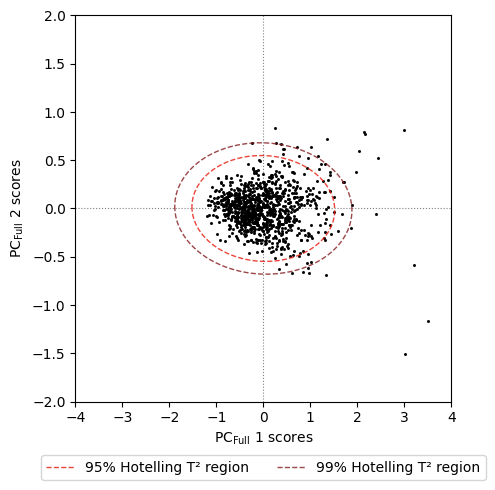

In [11]:
from scipy.stats import f

def hotelling_t2_ellipse(x, y, confidence=0.95, n_points=500):
    """
    Hotelling T² region for a 2D PCA score plot.
    """
    xy = np.column_stack([x, y])
    xy = xy[~np.isnan(xy).any(axis=1)]
    n, p = xy.shape   # p = 2 here

    # Center and covariance
    mean = xy.mean(axis=0)
    cov = np.cov(xy, rowvar=False)

    # Hotelling T² critical value
    t2_crit = (p * (n - 1) / (n - p) * f.ppf(confidence, p, n - p))
    
    # Eigenvectors/eigenvalues determine ellipse orientation and axes
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort largest eigenvalue first
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Unit circle
    theta = np.linspace(0, 2 * np.pi, n_points)
    circle = np.vstack([np.cos(theta), np.sin(theta)])

    # Transform circle into Hotelling ellipse
    ellipse = (
        eigvecs
        @ np.diag(np.sqrt(eigvals * t2_crit))
        @ circle
    )
    ellipse[0, :] += mean[0]
    ellipse[1, :] += mean[1]
    return ellipse

# Keep complete PC1/PC2 scores
plot_df = df_scores[["subject_key", "PC1", "PC2"]].dropna().copy()

# Hotelling regions
ellipse95 = hotelling_t2_ellipse(plot_df["PC1"],plot_df["PC2"],confidence=0.95)
ellipse99 = hotelling_t2_ellipse(plot_df["PC1"],plot_df["PC2"],confidence=0.99)

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    plot_df["PC1"],plot_df["PC2"],
    s=1.5,alpha=0.9, color="black")

ax.axhline(0,linestyle=":",color="black",linewidth=0.8, alpha=0.5)
ax.axvline(0, linestyle=":",color="black",linewidth=0.8, alpha=0.5)

ax.plot(
    ellipse95[0],ellipse95[1],
    linewidth=1,alpha=0.8,
    linestyle="--",color="#E7180B",
    label="95% Hotelling T² region"
)

ax.plot(
    ellipse99[0], ellipse99[1],
    linewidth=1, alpha=0.8,
    linestyle="--",color="#82181A",
    label="99% Hotelling T² region")

ax.set_xlim([-4,4])
ax.set_ylim([-2,2])


ax.set_xlabel(rf"$\mathrm{{PC}}_{{\mathrm{{Full}}}}\ 1$ scores")
ax.set_ylabel(rf"$\mathrm{{PC}}_{{\mathrm{{Full}}}}\ 2$ scores")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()

fig.savefig(
    FIGURES_DIR / "panel_3_PC1_PC2_scatterplot.svg",
    format="svg",
    bbox_inches="tight")


plt.show()

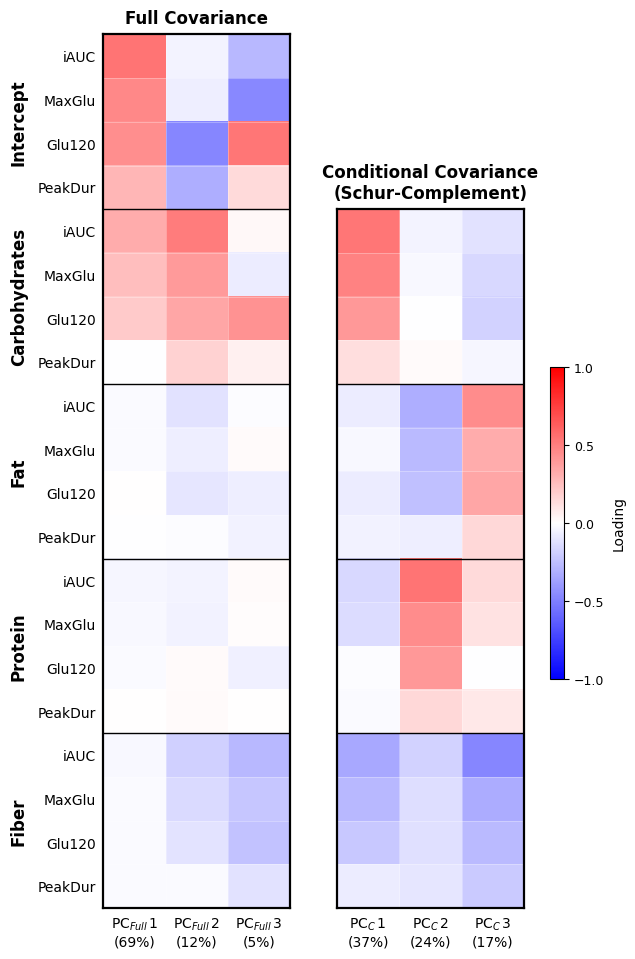

In [12]:
def plot_pc_loadings_with_schur(
    G,
    labels,
    *,
    full_loadings=None,
    full_variance_explained=None,
    n_components=3,
    outcome_order=(
        "positive_iAUC",
        "max_glucose",
        "end_glucose",
        "peak_duration",
    ),
    effect_order=("Intercept", "Carb", "Fat", "Protein", "Fiber"),
    outcome_display=None,
    effect_display=None,
    save_path=None,
    figsize=(7.2, 10.4),
    cmap="bwr",
    rcond=1e-12,
    #panel_label="(a)",
):
    """Plot full-covariance and intercept-conditioned PCA loadings.

    The conditional covariance is the Schur complement
    G[S,S] - G[S,I] @ pinv(G[I,I]) @ G[I,S], where I contains the
    outcome-specific random intercepts and S contains the random slopes.
    Labels must have the form ``outcome|effect`` used above.
    """
    outcome_display = outcome_display or {
        "positive_iAUC": "iAUC",
        "max_glucose": "MaxGlu",
        "end_glucose": "Glu120",
        "peak_duration": "PeakDur",
    }
    effect_display = effect_display or {
        "Intercept": "Intercept",
        "Carb": "Carbohydrates",
        "Fat": "Fat",
        "Protein": "Protein",
        "Fiber": "Fiber",
    }

    G = np.asarray(G, dtype=float)
    labels = list(labels)
    if G.ndim != 2 or G.shape[0] != G.shape[1]:
        raise ValueError("G must be a square covariance matrix.")
    if len(labels) != G.shape[0]:
        raise ValueError("labels must contain one entry per row/column of G.")
    if not effect_order or effect_order[0] != "Intercept":
        raise ValueError("effect_order must start with 'Intercept'.")

    G = 0.5 * (G + G.T)
    parsed = []
    for label in labels:
        parts = str(label).split("|", 1)
        if len(parts) != 2:
            raise ValueError(f"Expected an 'outcome|effect' label, got {label!r}.")
        parsed.append(tuple(parts))

    key_to_index = {key: i for i, key in enumerate(parsed)}
    if len(key_to_index) != len(parsed):
        raise ValueError("labels must be unique.")

    full_keys = [
        (outcome, effect)
        for effect in effect_order
        for outcome in outcome_order
    ]
    missing = [key for key in full_keys if key not in key_to_index]
    if missing:
        raise ValueError(f"G is missing requested outcome/effect pairs: {missing}")

    full_indices = [key_to_index[key] for key in full_keys]
    intercept_keys = [(outcome, "Intercept") for outcome in outcome_order]
    slope_keys = [key for key in full_keys if key[1] != "Intercept"]
    intercept_indices = [key_to_index[key] for key in intercept_keys]
    slope_indices = [key_to_index[key] for key in slope_keys]

    if n_components < 1 or n_components > min(len(full_indices), len(slope_indices)):
        raise ValueError("n_components is outside the available PCA dimensions.")

    def _eigendecompose(covariance):
        covariance = 0.5 * (covariance + covariance.T)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[order]
        eigenvectors = eigenvectors[:, order]
        nonnegative = np.clip(eigenvalues, 0, None)
        total = nonnegative.sum()
        if not np.isfinite(total) or total <= 0:
            raise ValueError("The covariance matrix has no positive variance.")
        return eigenvalues, eigenvectors, nonnegative / total

    # Use the existing full loadings when supplied so their signs remain
    # consistent with the PC scores already returned by covariance_pca.
    ordered_labels = [labels[i] for i in full_indices]
    full_covariance = G[np.ix_(full_indices, full_indices)]
    full_eigenvalues, calculated_full_loadings, calculated_full_var = (
        _eigendecompose(full_covariance)
    )
    pc_columns = [f"PC{i + 1}" for i in range(n_components)]

    if full_loadings is None:
        full_values = calculated_full_loadings[:, :n_components]
    elif isinstance(full_loadings, pd.DataFrame):
        full_values = full_loadings.loc[ordered_labels, pc_columns].to_numpy(float)
    else:
        full_loadings = np.asarray(full_loadings, dtype=float)
        if full_loadings.shape[0] != len(labels):
            raise ValueError("Array-like full_loadings must use the original label order.")
        full_values = full_loadings[full_indices, :n_components]

    if full_variance_explained is None:
        full_var = calculated_full_var[:n_components]
    else:
        full_var = np.asarray(full_variance_explained, dtype=float).ravel()[:n_components]
        if len(full_var) != n_components:
            raise ValueError("full_variance_explained has too few components.")

    G_ii = G[np.ix_(intercept_indices, intercept_indices)]
    G_si = G[np.ix_(slope_indices, intercept_indices)]
    G_is = G[np.ix_(intercept_indices, slope_indices)]
    G_ss = G[np.ix_(slope_indices, slope_indices)]
    G_conditional = G_ss - G_si @ np.linalg.pinv(
        G_ii, rcond=rcond, hermitian=True
    ) @ G_is
    G_conditional = 0.5 * (G_conditional + G_conditional.T)

    conditional_eigenvalues, conditional_vectors, conditional_var = (
        _eigendecompose(G_conditional)
    )
    conditional_values = conditional_vectors[:, :n_components].copy()

    # PCA signs are arbitrary. Align each conditional component to the
    # matching full-PC slope pattern to make the two panels comparable.
    full_slope_values = full_values[len(outcome_order):, :]
    for component in range(n_components):
        alignment = np.dot(
            conditional_values[:, component],
            full_slope_values[:, component],
        )
        if alignment < 0:
            conditional_values[:, component] *= -1
        elif np.isclose(alignment, 0):
            anchor = np.argmax(np.abs(conditional_values[:, component]))
            if conditional_values[anchor, component] < 0:
                conditional_values[:, component] *= -1

    n_outcomes = len(outcome_order)
    n_effects = len(effect_order)
    fig = plt.figure(figsize=figsize)
    grid = fig.add_gridspec(
        n_effects,
        3,
        width_ratios=(1, 1, 0.08),
        left=0.28,
        right=0.95,
        bottom=0.08,
        top=0.92,
        wspace=0.36,
        hspace=0.0,
    )
    ax_full = fig.add_subplot(grid[:, 0])
    ax_conditional = fig.add_subplot(grid[1:, 1])
    #colorbar_row = min(n_effects - 1, n_effects // 2)
    #ax_colorbar = fig.add_subplot(grid[colorbar_row, 2])
    ax_colorbar = fig.add_axes([0.90, 0.3, 0.02, 0.3])

    image = ax_full.imshow(
        full_values, cmap=cmap, vmin=-1, vmax=1, aspect="auto",
        interpolation="nearest",
    )
    ax_conditional.imshow(
        conditional_values, cmap=cmap, vmin=-1, vmax=1, aspect="auto",
        interpolation="nearest",
    )

    def _style_heatmap(axis, n_rows, xlabels, title, n_groups):
        axis.set_title(title, fontsize=12, fontweight="bold", pad=8)
        axis.set_xticks(range(n_components), labels=xlabels, fontsize=10)
        axis.tick_params(axis="x", length=0, pad=6)
        axis.set_xticks(np.arange(-0.5, n_components, 1), minor=True)
        axis.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
        axis.grid(which="minor", color="white", linewidth=0.6, alpha=0.35)
        axis.tick_params(which="minor", bottom=False, left=False)
        for boundary in range(1, n_groups):
            axis.axhline(
                boundary * n_outcomes - 0.5, color="black", linewidth=1
            )
        for spine in axis.spines.values():
            spine.set_visible(True)
            spine.set_color("black")
            spine.set_linewidth(1.6)

    full_xlabels = [
        rf"$\mathrm{{PC}}_{{\mathit{{Full}}}}\,{i + 1}$"
        + f"\n({100 * full_var[i]:.0f}%)"
        for i in range(n_components)
    ]
    conditional_xlabels = [
        rf"$\mathrm{{PC}}_{{C}}\,{i + 1}$"
        + f"\n({100 * conditional_var[i]:.0f}%)"
        for i in range(n_components)
    ]
    _style_heatmap(
        ax_full,
        len(full_keys),
        full_xlabels,
        "Full Covariance",
        n_effects,
    )
    _style_heatmap(
        ax_conditional,
        len(slope_keys),
        conditional_xlabels,
        "Conditional Covariance\n(Schur-Complement)",
        n_effects - 1,
    )

    row_labels = [outcome_display[outcome] for outcome, _ in full_keys]
    ax_full.set_yticks(range(len(full_keys)), labels=row_labels, fontsize=10)
    ax_full.tick_params(axis="y", length=0, pad=5)
    ax_conditional.set_yticks([])

    for group, effect in enumerate(effect_order):
        center = group * n_outcomes + (n_outcomes - 1) / 2
        ax_full.text(
            -0.45,
            center,
            effect_display.get(effect, effect),
            transform=ax_full.get_yaxis_transform(),
            ha="center",
            va="center",
            rotation=90,
            fontsize=12,
            fontweight="bold",
            clip_on=False,
        )

    colorbar = fig.colorbar(
        image,
        cax=ax_colorbar,
        ticks=(-1, -0.5, 0, 0.5, 1),
    )
    colorbar.set_label("Loading", rotation=90, labelpad=5)
    colorbar.ax.tick_params(labelsize=9)
    #if panel_label:
    #    fig.text(0.025, 0.965, panel_label, fontsize=18, fontweight="bold")

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, format="svg", bbox_inches="tight")

    full_loading_table = pd.DataFrame(
        full_values, index=ordered_labels, columns=pc_columns
    )
    conditional_labels = [labels[i] for i in slope_indices]
    conditional_loading_table = pd.DataFrame(
        conditional_values, index=conditional_labels, columns=pc_columns
    )
    results = {
        "full_covariance": pd.DataFrame(
            full_covariance, index=ordered_labels, columns=ordered_labels
        ),
        "full_eigenvalues": full_eigenvalues,
        "full_loadings": full_loading_table,
        "full_variance_explained": pd.Series(full_var, index=pc_columns),
        "conditional_covariance": pd.DataFrame(
            G_conditional, index=conditional_labels, columns=conditional_labels
        ),
        "conditional_eigenvalues": conditional_eigenvalues,
        "conditional_loadings": conditional_loading_table,
        "conditional_variance_explained": pd.Series(
            conditional_var[:n_components], index=pc_columns
        ),
    }
    return fig, results


fig, pc_loading_results = plot_pc_loadings_with_schur(
    G=G_full,
    labels=labels,
    full_loadings=loadings,
    full_variance_explained=var_exp,
    save_path=FIGURES_DIR / "panel_3_PC_loadings.svg",
)
plt.show()

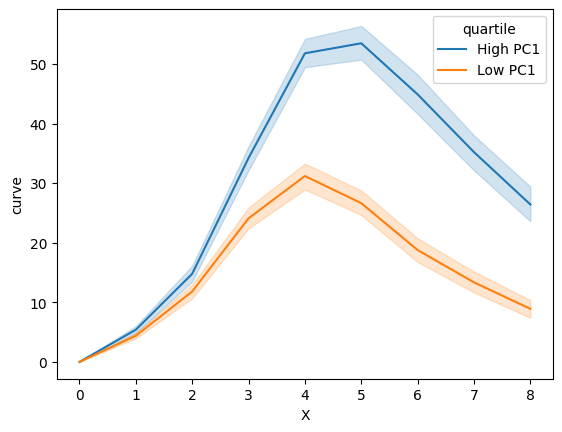

In [13]:
df_scores = pd.merge(meta_data, scores[["subject_key", "PC1", "PC2", "PC3"]])
std_meal_ppgr = data[data["is_standardized_meal"]==True].copy().reset_index()

std_meal_ppgr = pd.merge(std_meal_ppgr, df_scores[["subject_key", "PC1","PC2"]], on="subject_key")
df = std_meal_ppgr.copy()
s=df.assign(curve=[np.fromstring(a.strip("[]"),sep=",")-b for a,b in zip(df.ppgr_array,df.premeal_glucose)])
#s=s[s.curve.map(len).ge(9)].reset_index(drop=True)
s=s[s.curve.map(len).eq(9)].reset_index(drop=True)
p=s.groupby("subject_key").PC1.mean()
lo,hi=p.quantile([.25,.75])
s=s[s.subject_key.isin(p[(p<=lo)|(p>=hi)].index)].assign(quartile=lambda x:x.subject_key.map(lambda k:"Low PC1" if p[k]<=lo else "High PC1"))
m=s[["subject_key","quartile","curve"]].explode("curve")
m["X"]=m.groupby(level=0).cumcount()
m["curve"]=m.curve.astype(float)
m=m.groupby(["subject_key","quartile","X"],as_index=False).curve.mean()
sns.lineplot(m,x="X",y="curve",hue="quartile",errorbar=("ci",95))
plt.show()

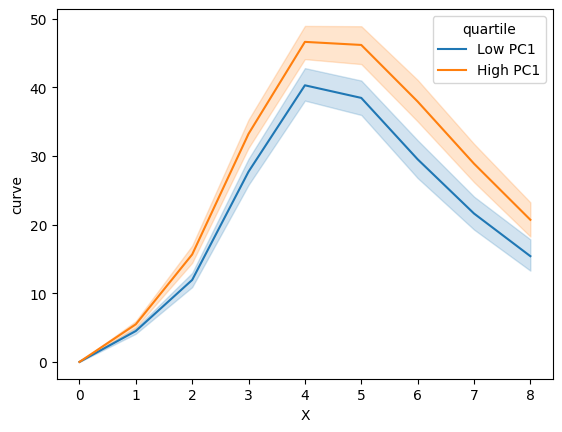

In [14]:
s=df.assign(curve=[np.fromstring(a.strip("[]"),sep=",")-b for a,b in zip(df.ppgr_array,df.premeal_glucose)])
#s=s[s.curve.map(len).ge(9)].reset_index(drop=True)
s=s[s.curve.map(len).eq(9)].reset_index(drop=True)
p=s.groupby("subject_key").PC2.mean()
lo,hi=p.quantile([.25,.75])
s=s[s.subject_key.isin(p[(p<=lo)|(p>=hi)].index)].assign(quartile=lambda x:x.subject_key.map(lambda k:"Low PC1" if p[k]<=lo else "High PC1"))
m=s[["subject_key","quartile","curve"]].explode("curve")
m["X"]=m.groupby(level=0).cumcount()
m["curve"]=m.curve.astype(float)
m=m.groupby(["subject_key","quartile","X"],as_index=False).curve.mean()
sns.lineplot(m,x="X",y="curve",hue="quartile",errorbar=("ci",95))
plt.show()

## 4. Associations with participant characteristics and standardized meals

### PC scores and CGM metrics

These analyses connect participant phenotype coordinates to participant-level CGM summaries.

In [15]:
df_cgm_metrics = pd.read_csv(CGM_METRICS_PATH, index_col=0)
df_cgm_metrics.head()

,subject_key,n_observations,start_time,end_time,n_days,mean_glucose,median_glucose,min_glucose,max_glucose,q1_glucose,...,MGN_error,MAGE,J_index,LBGI,HBGI,ADRR,MODD,CONGA24,GMI,eA1c
0,02ae3856ca04,1300,2018-11-26 08:00:00,2018-12-10 06:45:00,15,95.201169,94.77,44.10,183.96,83.88,...,unsupported operand type(s) for +: 'Timestamp'...,9.542,12.268841,1.955364,0.062971,10.168173,12.106015,3.800416,5.587212,4.944292
1,223h73,1386,2019-08-21 06:15:00,2019-11-13 03:00:00,17,115.540779,109.80,70.02,219.78,102.78,...,unsupported operand type(s) for +: 'Timestamp'...,22.749,18.305420,0.277840,0.608166,8.379888,14.999454,7.309503,6.073735,5.652989
2,22w6cq,1268,2020-01-26 07:45:00,2020-02-09 06:15:00,15,91.195694,88.02,64.98,148.50,79.74,...,unsupported operand type(s) for +: 'Timestamp'...,18.658,11.386916,2.558825,0.056012,9.006795,11.668639,5.786399,5.491401,4.804728
3,244bwh,1306,2020-08-31 10:45:00,2020-09-14 09:00:00,15,98.060995,96.30,57.60,158.94,90.90,...,unsupported operand type(s) for +: 'Timestamp'...,8.195,11.868266,1.043974,0.045043,5.430712,10.257157,4.177066,5.655619,5.043937
4,2857fm,1261,2019-10-01 05:45:00,2019-10-14 20:45:00,14,99.293481,98.46,68.04,146.52,91.08,...,unsupported operand type(s) for +: 'Timestamp'...,8.577,12.273983,1.029788,0.026504,5.694902,10.276845,3.543256,5.685100,5.086881


In [16]:
df_scores = pd.merge(scores, meta_data, on="subject_key")

df_scores_cgm=pd.merge(df_scores, df_cgm_metrics, on="subject_key")


# add pre-meal statistics
pre_meal_glucose = (
    data.groupby("subject_key")["premeal_glucose"]
        .agg(
            mean_premeal_glucose="mean",
            std_premeal_glucose="std"
        )
        .reset_index()
)
df_scores_cgm= pd.merge(df_scores_cgm, pre_meal_glucose, on="subject_key")


### add iAUC statistics : per grams, per meal types.
MIN_CARB = 5.0      # grams; below this the ratio is denominator noise
MIN_MEALS = 2       # cells with fewer meals get NaN for std

d = data[data["is_standardized_meal"]==0].copy()

# Exclude low-carbohydrate meals from the iAUC-to-carbohydrate ratio.
d["iAUC_per_carb"] = np.where(
    d["carb_eaten"] >= MIN_CARB,
    d["positive_iAUC"] / d["carb_eaten"].replace(0, np.nan),
    np.nan,
)

AGGS = dict(
    mean_iAUC=("positive_iAUC", "mean"),
    std_iAUC=("positive_iAUC", "std"),
    mean_iAUC_per_carb=("iAUC_per_carb", "mean"),
    std_iAUC_per_carb=("iAUC_per_carb", "std"),
    mean_carb=("carb_eaten", "mean"),
    n=("positive_iAUC", "size"),
    n_carb=("iAUC_per_carb", "count"),   # meals actually usable for the ratio
)

# 1) Overall stats, within each subject (all mealtimes pooled)
overall = d.groupby("subject_key").agg(**AGGS)
overall.columns = [
    c if c.startswith("n") else f"overall_{c}" for c in overall.columns
]
overall = overall.rename(columns={"n": "n_meals", "n_carb": "n_meals_carb"})

# 2) Stats per subject x mealtime_type
per_meal = d.groupby(["subject_key", "mealtime_type"]).agg(**AGGS)

# 3) Mask stats that rest on too few observations
per_meal.loc[per_meal["n"] < MIN_MEALS, ["std_iAUC"]] = np.nan
per_meal.loc[per_meal["n_carb"] < MIN_MEALS,
             ["mean_iAUC_per_carb", "std_iAUC_per_carb"]] = np.nan
overall.loc[overall["n_meals_carb"] < MIN_MEALS,
            ["overall_mean_iAUC_per_carb", "overall_std_iAUC_per_carb"]] = np.nan

# 4) One row per subject
wide = per_meal.unstack("mealtime_type")
wide.columns = [f"{stat}__{meal}" for stat, meal in wide.columns]

iAUC_per_subject = (
    overall.join(wide)
           .replace([np.inf, -np.inf], np.nan)
           .reset_index()
)

df_scores_cgm = pd.merge(df_scores_cgm,iAUC_per_subject, on="subject_key")

In [17]:
per_meal_stats = ["mean_iAUC", "std_iAUC", "mean_iAUC_per_carb", "std_iAUC_per_carb", "mean_carb"]
overall_stats  = ["overall_" + s for s in ["mean_iAUC", "std_iAUC", "mean_iAUC_per_carb", "std_iAUC_per_carb", "mean_carb"]]

meals = sorted(d["mealtime_type"].dropna().unique())
iauc_stats_columns = overall_stats + [f"{s}__{m}" for s in per_meal_stats for m in meals]

In [18]:
cgm_metrics_indices = [#'n_observations',
 #'start_time', 'end_time',
#'n_days',
    'mean_glucose','median_glucose','min_glucose',
 'max_glucose','q1_glucose','q3_glucose','interdaysd','interdaycv','intradaysd_mean',
 'intradaysd_median','intradaysd_sd','intradaycv_mean','intradaycv_median','intradaycv_sd',
 'TOR','TIR','POR','MAGE','J_index','LBGI','HBGI','ADRR','MODD',
 'CONGA24','GMI','eA1c']

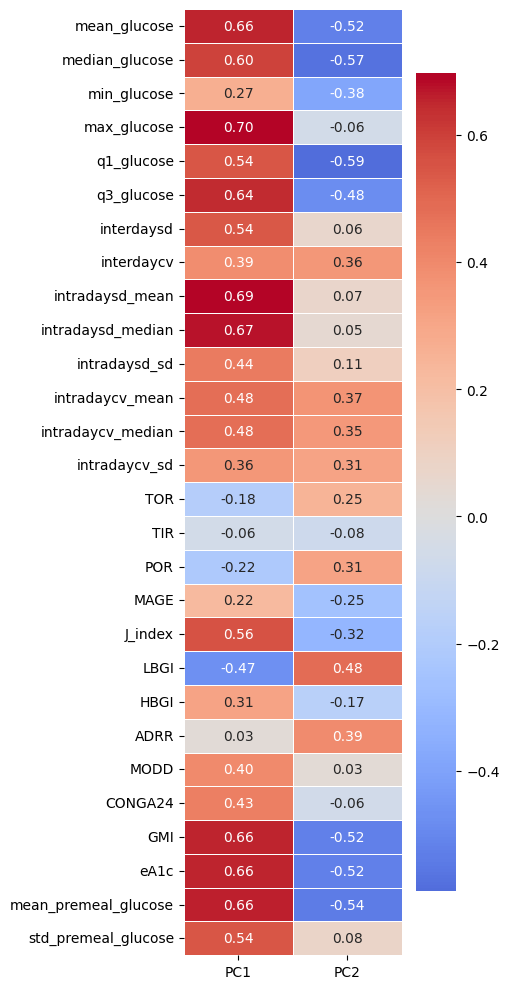

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = cgm_metrics_indices + ["PC1", "PC2", "mean_premeal_glucose", "std_premeal_glucose"]

corr = df_scores_cgm[cols].corr(method="pearson").loc[cgm_metrics_indices + ["mean_premeal_glucose", "std_premeal_glucose"], ["PC1", "PC2"]]

plt.figure(figsize=(5, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=.5)
plt.tight_layout()
plt.show()

In [20]:
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

COVARS = ["age", "gender_encoded", "bmi"]

# sex must be numeric
df_scores_cgm["gender_encoded"] = (df_scores_cgm["gender"].astype(str).str.lower() == "male").astype(int)

rows = []
for m in cgm_metrics_indices + ["mean_premeal_glucose", "std_premeal_glucose"]:
    row = {"metric": m}
    for pc in ["PC1", "PC2"]:
        adj = pg.partial_corr(data=df_scores_cgm, x=m, y=pc,
                              covar=COVARS, method="pearson").iloc[0]
        lo, hi = adj["CI95"]
        row[f"{pc}_r (95% CI)"] = f"{adj['r']:.2f} [{lo:.2f}, {hi:.2f}]"
        row[f"{pc}_p"] = adj["p_val"]
    rows.append(row)

res = pd.DataFrame(rows).set_index("metric")

# FDR across all metrics × both axes
p_all = res[["PC1_p", "PC2_p"]].to_numpy().ravel()
_, q_all = pg.multicomp(p_all, method="fdr_bh")
res[["PC1_q", "PC2_q"]] = q_all.reshape(-1, 2)

def sci(p, sig=1):
    """3.2e-05 -> '3.2 ×10⁻⁵'"""
    if p == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(p))))
    mant = p / 10**exp
    # guard against rounding pushing mantissa to 10.0
    if round(mant, sig) >= 10:
        mant, exp = mant / 10, exp + 1
    sup = str.maketrans("-0123456789", "⁻⁰¹²³⁴⁵⁶⁷⁸⁹")
    return f"{mant:.{sig}f} ×10{str(exp).translate(sup)}"
    
# tidy formatting + column order
#fmt = lambda p: f"{p:.3f}" if p >= 0.001 else "<0.001"
#for c in ["PC1_p", "PC2_p", "PC1_q", "PC2_q"]:
#    res[c] = res[c].map(fmt)
fmt = lambda p: f"{p:.3f}" if p >= 0.001 else "<0.001"

for c in ["PC1_p", "PC2_p"]:
    res[c] = res[c].map(fmt)
for c in ["PC1_q", "PC2_q"]:
    res[c] = res[c].map(sci)

res = res[["PC1_r (95% CI)",  "PC1_q",
           "PC2_r (95% CI)", "PC2_q"]]
res

,PC1_r (95% CI),PC1_q,PC2_r (95% CI),PC2_q
metric,,,,
mean_glucose,"0.63 [0.59, 0.67]",4.5 ×10⁻¹¹¹,"-0.54 [-0.58, -0.50]",6.2 ×10⁻⁷⁶
median_glucose,"0.57 [0.53, 0.61]",3.7 ×10⁻⁸⁷,"-0.59 [-0.63, -0.55]",2.6 ×10⁻⁹²
min_glucose,"0.23 [0.17, 0.29]",1.1 ×10⁻¹³,"-0.39 [-0.44, -0.33]",4.9 ×10⁻³⁶
max_glucose,"0.68 [0.64, 0.71]",5.0 ×10⁻¹³³,"-0.07 [-0.14, -0.01]",2.4 ×10⁻²
q1_glucose,"0.52 [0.47, 0.56]",2.2 ×10⁻⁶⁹,"-0.61 [-0.65, -0.57]",5.2 ×10⁻¹⁰⁰
q3_glucose,"0.62 [0.58, 0.66]",2.8 ×10⁻¹⁰⁵,"-0.50 [-0.54, -0.45]",1.2 ×10⁻⁶²
interdaysd,"0.52 [0.47, 0.56]",2.0 ×10⁻⁶⁸,"0.05 [-0.01, 0.11]",1.1 ×10⁻¹
interdaycv,"0.38 [0.33, 0.43]",3.9 ×10⁻³⁵,"0.35 [0.29, 0.40]",2.6 ×10⁻²⁹
intradaysd_mean,"0.67 [0.63, 0.70]",6.3 ×10⁻¹²⁷,"0.06 [-0.00, 0.12]",7.8 ×10⁻²


### PC scores, demographics, and adiposity

Relate full-fit PC scores to demographics and adiposity measures, then test the added explanatory value of adiposity beyond age and sex using one row per participant.

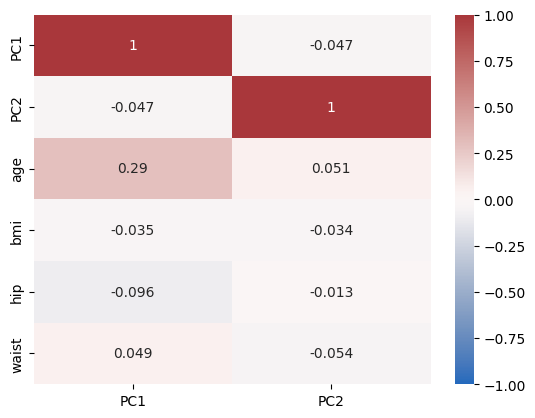

In [21]:
# merge participant informations and PC scores


df_scores = pd.merge(scores, meta_data, on="subject_key")
std_meals_mean = data.groupby(["subject_key", 
                                  "standardized_meal_id"])[prediction_metrics].mean().reset_index()

df_scores = pd.merge(df_scores, std_meals_mean)


sns.heatmap(df_scores[["PC1", "PC2", "age", "bmi", "hip", 
                       "waist"]].corr()[["PC1","PC2"]], cmap="vlag", annot=True, vmin=-1, vmax=1)
plt.show()

In [22]:
import numpy as np, pandas as pd
import statsmodels.api as sm
from scipy import stats

# ---------- one row per subject ----------
cols = ['subject_key','PC1','PC2','age','gender','bmi',
        'height','weight','waist','hip']
d = df_scores.drop_duplicates('subject_key')[cols].copy()
d['sex'] = d['gender'].map({'Male':1,'male':1,'M':1,'Female':0,'female':0,'F':0})
if d['sex'].isna().any():
    d['sex'] = pd.factorize(d['gender'])[0]

# Derived central-adiposity indices.
d['whr']  = d['waist'] / d['hip']          # waist-to-hip
d['whtr'] = d['waist'] / d['height']       # waist-to-height
feats = ['age','sex','bmi','height','weight','waist','hip','whr','whtr']

def z(s): return (s - s.mean())/s.std(ddof=1)

In [23]:
# univariate: each feature vs each axis (standardized beta = r)
print("Univariate partial correlations (standardized beta, 95% CI)")
rows=[]
for pc in ['PC1','PC2']:
    for f in feats:
        s = d.dropna(subset=[pc,f])
        r,p = stats.pearsonr(z(s[f]), z(s[pc]))
        n = len(s)
        se = 1/np.sqrt(n-3); zr = np.arctanh(r)               # Fisher CI
        lo,hi = np.tanh(zr-1.96*se), np.tanh(zr+1.96*se)
        rows.append([pc,f,n,round(r,3),round(lo,3),round(hi,3),f"{p:.1e}"])
print(pd.DataFrame(rows,columns=['axis','feature','n','beta','lo','hi','p']).to_string(index=False))

Univariate partial correlations (standardized beta, 95% CI)
axis feature   n   beta     lo     hi       p
 PC1     age 992  0.304  0.247  0.360 1.0e-22
 PC1     sex 992  0.116  0.054  0.177 2.5e-04
 PC1     bmi 992 -0.033 -0.095  0.029 3.0e-01
 PC1  height 992 -0.021 -0.083  0.041 5.1e-01
 PC1  weight 992 -0.042 -0.104  0.020 1.8e-01
 PC1   waist 989  0.061 -0.002  0.122 5.7e-02
 PC1     hip 989 -0.098 -0.159 -0.036 2.0e-03
 PC1     whr 989  0.144  0.082  0.205 5.4e-06
 PC1    whtr 989  0.078  0.016  0.140 1.4e-02
 PC2     age 992  0.059 -0.003  0.121 6.3e-02
 PC2     sex 992 -0.087 -0.148 -0.024 6.3e-03
 PC2     bmi 992 -0.025 -0.088  0.037 4.2e-01
 PC2  height 992 -0.095 -0.157 -0.033 2.6e-03
 PC2  weight 992 -0.066 -0.128 -0.004 3.6e-02
 PC2   waist 989 -0.048 -0.110  0.015 1.4e-01
 PC2     hip 989 -0.006 -0.068  0.056 8.5e-01
 PC2     whr 989 -0.049 -0.111  0.013 1.2e-01
 PC2    whtr 989 -0.019 -0.081  0.043 5.5e-01


In [24]:
# Incremental variance explained by adiposity beyond age and sex (F test, delta R²).
# block = bmi,weight,waist,hip  ;  baseline = age,sex
CONT = ['age','bmi','waist','hip']   # sex handled separately

def z(v):
    return (v - v.mean()) / v.std()           # pandas std => ddof=1

def ols_std(pc, Xc, data):
    X = data[Xc].copy()
    for c in Xc:
        if c in CONT:
            X[c] = z(X[c])
    X = sm.add_constant(X)
    return sm.OLS(z(data[pc]), X).fit()
    
rows=[]
for pc in ['PC1','PC2']:
    s = d.dropna(subset=[pc,'age','sex','bmi','waist','hip'])
    A = ols_std(pc,['age','sex'],s)
    B = ols_std(pc,['age','sex','bmi','waist','hip'],s)
    F = B.compare_f_test(A)
    print(pc + "\n")
    print(B.summary())
    print()
    rows.append([pc,len(s),round(A.rsquared,3),round(B.rsquared,3),
                 round(B.rsquared-A.rsquared,3),round(F[0],2),f"{F[1]:.1e}",
                 round((B.rsquared-A.rsquared)/(1-B.rsquared),3)])
print("===============\n\n\nSTEP 2  Adiposity block over age+sex (nested F-test)")
print(pd.DataFrame(rows,columns=['axis','n','R2_agesex','R2_full','dR2','F','p','f2']).to_string(index=False))

PC1

                            OLS Regression Results                            
Dep. Variable:                    PC1   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     26.91
Date:                Mon, 07 Sep 2026   Prob (F-statistic):           1.45e-25
Time:                        09:30:06   Log-Likelihood:                -1339.4
No. Observations:                 989   AIC:                             2691.
Df Residuals:                     983   BIC:                             2720.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0995      0.048     -2.083    

In [25]:
rows = []
coefficient_tables = []

for pc in ["PC1", "PC2"]:
    s = d.dropna(
        subset=[pc, "age", "sex", "bmi", "waist", "hip"]
    )

    A = ols_std(pc, ["age", "sex"], s)
    B = ols_std(
        pc,
        ["age", "sex", "bmi", "waist", "hip"],
        s,
    )

    F_stat, p_value, df_diff = B.compare_f_test(A)

    rows.append({
        "axis": pc,
        "n": len(s),
        "R2_agesex": A.rsquared,
        "R2_full": B.rsquared,
        "dR2": B.rsquared - A.rsquared,
        "F": F_stat,
        "p": p_value,
        "df_diff": df_diff,
        "f2": (
            (B.rsquared - A.rsquared)
            / (1 - B.rsquared)
        ),
    })

    # Save coefficients from both models
    for model_formula, model in [
        (f"{pc} ~ age + sex", A),
        (f"{pc} ~ age + sex + bmi + waist + hip", B),
    ]:
        ci = model.conf_int()
    
        coefficient_tables.append(
            pd.DataFrame({
                "axis": pc,
                "model": model_formula,
                "term": model.params.index,
                "estimate": model.params.values,
                "std_error": model.bse.values,
                "t": model.tvalues.values,
                "p": model.pvalues.values,
                "CI_95_low": ci.iloc[:, 0].values,
                "CI_95_high": ci.iloc[:, 1].values,
            })
        )

block_results = pd.DataFrame(rows)
coefficient_results = pd.concat(
    coefficient_tables,
    ignore_index=True,
)

block_results.to_csv(RESULTS_DIR/
    "adiposity_block_results.csv",
    index=False,
)

coefficient_results.to_csv(RESULTS_DIR/
    "adiposity_model_coefficients.csv",
    index=False,
)

display(block_results)
display(coefficient_results)

,axis,n,R2_agesex,R2_full,dR2,F,p,df_diff,f2
0,PC1,989,0.101768,0.120404,0.018636,6.942327,0.000126,3.0,0.021187
1,PC2,989,0.012367,0.013174,0.000808,0.268141,0.848390,3.0,0.000818


,axis,model,term,estimate,std_error,t,p,CI_95_low,CI_95_high
0,PC1,PC1 ~ age + sex,const,-0.076959,0.040100,-1.919164,5.525203e-02,-0.155650,0.001733
1,PC1,PC1 ~ age + sex,age,0.298134,0.030324,9.831640,7.973122e-22,0.238627,0.357641
2,PC1,PC1 ~ age + sex,sex,0.178248,0.061190,2.913030,3.660165e-03,0.058171,0.298326
3,PC1,PC1 ~ age + sex + bmi + waist + hip,const,-0.099464,0.047747,-2.083166,3.749401e-02,-0.193161,-0.005767
4,PC1,PC1 ~ age + sex + bmi + waist + hip,age,0.328281,0.033068,9.927415,3.364308e-22,0.263389,0.393173
5,PC1,PC1 ~ age + sex + bmi + waist + hip,sex,0.230375,0.086223,2.671838,7.668473e-03,0.061172,0.399578
6,PC1,PC1 ~ age + sex + bmi + waist + hip,bmi,-0.037717,0.052948,-0.712351,4.764163e-01,-0.141621,0.066186
7,PC1,PC1 ~ age + sex + bmi + waist + hip,waist,-0.044276,0.065637,-0.674556,5.001165e-01,-0.173081,0.084529
8,PC1,PC1 ~ age + sex + bmi + waist + hip,hip,-0.079689,0.045225,-1.762054,7.837095e-02,-0.168437,0.009060
9,PC2,PC2 ~ age + sex,const,0.081230,0.042048,1.931833,5.366637e-02,-0.001284,0.163745


### Adjusted PC–CGM correlations and CSV export

In [26]:
cgm_metrics_indices = [#'n_observations',
 #'start_time', 'end_time',
#'n_days',
    'mean_glucose','median_glucose','min_glucose',
 'max_glucose','q1_glucose','q3_glucose','interdaysd','interdaycv','intradaysd_mean',
 'intradaysd_median','intradaysd_sd','intradaycv_mean','intradaycv_median','intradaycv_sd',
 'TOR','TIR','POR','MAGE','J_index','LBGI','HBGI','ADRR','MODD',
 'CONGA24','GMI','eA1c']

import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt

COVARS = ["age", "gender_encoded", "bmi"]   

# sex must be numeric
df_scores_cgm["gender_encoded"] = (df_scores_cgm["gender"].astype(str).str.lower() == "male").astype(int)

rows = []
for m in cgm_metrics_indices + ["mean_premeal_glucose", "std_premeal_glucose"]:
    row = {"metric": m}
    for pc in ["PC1", "PC2"]:
        adj = pg.partial_corr(data=df_scores_cgm, x=m, y=pc,
                              covar=COVARS, method="pearson").iloc[0]
        lo, hi = adj["CI95"]
        row[f"{pc}_r (95% CI)"] = f"{adj['r']:.2f} [{lo:.2f}, {hi:.2f}]"
        row[f"{pc}_p"] = adj["p_val"]
        row[f"N"] = int(adj["n"])  # effective number of observations
    rows.append(row)

res = pd.DataFrame(rows).set_index("metric")

# FDR across all metrics × both axes
p_all = res[["PC1_p", "PC2_p"]].to_numpy().ravel()
_, q_all = pg.multicomp(p_all, method="fdr_bh")
res[["PC1_q", "PC2_q"]] = q_all.reshape(-1, 2)

# tidy formatting + column order
#fmt = lambda p: f"{p:.3f}" if p >= 0.001 else "<0.001"
#for c in ["PC1_p", "PC2_p", "PC1_q", "PC2_q"]:
#    res[c] = res[c].map(fmt)


    
def sci(p, sig=1):
    if p == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(p))))
    mant = p / 10**exp
    if round(mant, sig) >= 10:
        mant, exp = mant / 10, exp + 1
    return f"{mant:.{sig}f} × 10^{exp}"   # '3.2 x 10^-5'

for c in ["PC1_p", "PC2_p"]:
    res[c] = res[c].map(fmt)
for c in ["PC1_q", "PC2_q"]:
    res[c] = res[c].map(sci)
    

res["PC1_q_num"] = q_all.reshape(-1, 2)[:, 0]
res["PC2_q_num"] = q_all.reshape(-1, 2)[:, 1]

res["Covariates"] = "age + sex + BMI"


res = res[["Covariates","PC1_r (95% CI)",  "PC1_q",
           "PC2_r (95% CI)", "PC2_q", "N"]]


    

res.to_csv(RESULTS_DIR/
    "PC_CGM_metrics_partial_correlations.csv",
    index=True,
    index_label="metric",
    encoding="utf-8-sig"
)

res

,Covariates,PC1_r (95% CI),PC1_q,PC2_r (95% CI),PC2_q,N
metric,,,,,,
mean_glucose,age + sex + BMI,"0.63 [0.59, 0.67]",4.5 × 10^-111,"-0.54 [-0.58, -0.50]",6.2 × 10^-76,992
median_glucose,age + sex + BMI,"0.57 [0.53, 0.61]",3.7 × 10^-87,"-0.59 [-0.63, -0.55]",2.6 × 10^-92,992
min_glucose,age + sex + BMI,"0.23 [0.17, 0.29]",1.1 × 10^-13,"-0.39 [-0.44, -0.33]",4.9 × 10^-36,992
max_glucose,age + sex + BMI,"0.68 [0.64, 0.71]",5.0 × 10^-133,"-0.07 [-0.14, -0.01]",2.4 × 10^-2,992
q1_glucose,age + sex + BMI,"0.52 [0.47, 0.56]",2.2 × 10^-69,"-0.61 [-0.65, -0.57]",5.2 × 10^-100,992
q3_glucose,age + sex + BMI,"0.62 [0.58, 0.66]",2.8 × 10^-105,"-0.50 [-0.54, -0.45]",1.2 × 10^-62,992
interdaysd,age + sex + BMI,"0.52 [0.47, 0.56]",2.0 × 10^-68,"0.05 [-0.01, 0.11]",1.1 × 10^-1,992
interdaycv,age + sex + BMI,"0.38 [0.33, 0.43]",3.9 × 10^-35,"0.35 [0.29, 0.40]",2.6 × 10^-29,992
intradaysd_mean,age + sex + BMI,"0.67 [0.63, 0.70]",6.3 × 10^-127,"0.06 [-0.00, 0.12]",7.8 × 10^-2,992


### Standardized-meal associations and extreme-quartile comparisons

Standardized-meal outcomes are analyzed against the same full-model phenotype coordinates.

In [27]:
"""Shared participant-table construction for Supplementary Note 6.

The analysis cohort is restricted globally to participants with PC1, PC2,
mean_glucose, and interdaycv. Each standardized-meal analysis then uses one
meal-specific complete-case sample, shared across all four outcomes for that
meal.
"""

from __future__ import annotations

import numpy as np
import pandas as pd


OUTCOMES = ["max_glucose", "end_glucose", "positive_iAUC", "peak_duration"]
MEALS = ["A", "B", "C"]
PCS = ["PC1", "PC2"]
DEMO = ["age", "sex", "bmi"]
CGM_METRICS = ["mean_glucose", "interdaycv"]

PC_LABEL = {"PC1": "PCFull1", "PC2": "PCFull2"}
OUTCOME_LABEL = {
    "max_glucose": "MaxGlu",
    "end_glucose": "Glu120",
    "positive_iAUC": "iAUC",
    "peak_duration": "PeakDuration",
}
MEAL_LABEL = {
    "A": "glucose drink",
    "B": "white bread",
    "C": "white bread + butter",
}


def _require_columns(data: pd.DataFrame, required: list[str], name: str) -> None:
    missing = [column for column in required if column not in data.columns]
    if missing:
        raise KeyError(f"{name} is missing required columns: {missing}")


def _participant_cgm_table(df_cgm: pd.DataFrame) -> pd.DataFrame:
    """Validate and collapse CGM metrics to one row per participant."""
    required = ["subject_key", *CGM_METRICS]
    _require_columns(df_cgm, required, "df_cgm")

    cgm = df_cgm[required].copy()
    if cgm["subject_key"].isna().any():
        raise ValueError("df_cgm contains missing subject_key values.")

    for column in CGM_METRICS:
        numeric = pd.to_numeric(cgm[column], errors="coerce")
        invalid = cgm[column].notna() & numeric.isna()
        if invalid.any():
            examples = cgm.loc[invalid, column].astype(str).unique()[:5].tolist()
            raise ValueError(
                f"df_cgm['{column}'] contains non-numeric values. "
                f"Examples: {examples}"
            )
        cgm[column] = numeric

    cgm[CGM_METRICS] = cgm[CGM_METRICS].replace([np.inf, -np.inf], np.nan)

    distinct = cgm.groupby("subject_key")[CGM_METRICS].nunique(dropna=True)
    conflicting = distinct.gt(1).any(axis=1)
    if conflicting.any():
        bad_ids = distinct.index[conflicting].tolist()
        raise ValueError(
            f"{len(bad_ids)} participants have conflicting participant-level "
            f"CGM values. Example subject_key values: {bad_ids[:10]}"
        )

    return cgm.groupby("subject_key", sort=False)[CGM_METRICS].first()


def build_participant_table(
    df_scores: pd.DataFrame,
    df_cgm: pd.DataFrame,
    *,
    verbose: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    """Return the global cohort, glucose-drink common sample, and sex coding."""
    required = [
        "subject_key",
        "standardized_meal_id",
        "PC1",
        "PC2",
        "age",
        "gender",
        "bmi",
        *OUTCOMES,
    ]
    _require_columns(df_scores, required, "df_scores")

    scores = df_scores.copy()
    duplicate_count = scores.duplicated(
        ["subject_key", "standardized_meal_id"]
    ).sum()
    if duplicate_count:
        raise ValueError(
            f"Found {duplicate_count} duplicate participant x meal rows. "
            "Average repeated administrations upstream before running this analysis."
        )

    outcomes_wide = scores.pivot(
        index="subject_key",
        columns="standardized_meal_id",
        values=OUTCOMES,
    )
    outcomes_wide.columns = [
        f"{outcome}_{meal}" for outcome, meal in outcomes_wide.columns
    ]

    participant = scores.groupby("subject_key")[[
        "PC1",
        "PC2",
        "age",
        "gender",
        "bmi",
    ]].first()

    gender = participant["gender"].astype("category")
    if len(gender.cat.categories) != 2:
        raise ValueError(
            "This analysis expects exactly two observed gender categories. "
            f"Found: {list(gender.cat.categories)}"
        )
    participant["sex"] = gender.cat.codes.astype(float)
    participant.loc[gender.isna(), "sex"] = np.nan
    sex_map = dict(enumerate(gender.cat.categories))

    cgm = _participant_cgm_table(df_cgm)
    if len(participant.index.intersection(cgm.index)) == 0:
        raise ValueError(
            "No subject_key values match between df_scores and df_cgm. "
            "Check whether the ID columns use different data types."
        )

    full = participant.join(outcomes_wide, how="left").join(cgm, how="left")
    full[PCS + CGM_METRICS] = full[PCS + CGM_METRICS].replace(
        [np.inf, -np.inf], np.nan
    )

    pc_complete = full.dropna(subset=PCS)
    missing_cgm = pc_complete[CGM_METRICS].isna().any(axis=1)
    analysis = pc_complete.loc[~missing_cgm].copy()
    glucose_outcomes = [f"{outcome}_A" for outcome in OUTCOMES]
    common_glucose_sample = analysis.dropna(subset=[*DEMO, *glucose_outcomes]).copy()

    if verbose:
        print("[S6 setup]")
        print(f"  sex coding                     : {sex_map}")
        print(f"  participants with both PCs     : n = {len(pc_complete)}")
        print(f"  removed for mean/CV missingness: n = {int(missing_cgm.sum())}")
        print(f"  global analysis cohort         : n = {len(analysis)}")
        print(f"  glucose-drink common sample    : n = {len(common_glucose_sample)}")

    return analysis, common_glucose_sample, sex_map


def build_meal_samples(
    participant_table: pd.DataFrame,
    *,
    verbose: bool = True,
) -> dict[str, pd.DataFrame]:
    """Create one complete-case sample per meal, shared by all four outcomes."""
    samples: dict[str, pd.DataFrame] = {}

    for meal in MEALS:
        meal_outcomes = [f"{outcome}_{meal}" for outcome in OUTCOMES]
        required = [*PCS, *DEMO, *CGM_METRICS, *meal_outcomes]
        sample = participant_table.replace([np.inf, -np.inf], np.nan).dropna(
            subset=required
        )
        samples[meal] = sample

    if verbose:
        print("[Meal-specific complete-case samples]")
        for meal in MEALS:
            print(f"  {MEAL_LABEL[meal]:22s}: n = {len(samples[meal])}")

    return samples

In [28]:
"""Main-text standardized-meal analyses for Supplementary Note 6.

This script contains only the analyses used in the manuscript section:

1. Unadjusted Pearson correlations between PCFull1/PCFull2 and each
   standardized-meal response.
2. Nested regressions testing whether each PC explains additional variance in
   each response after age, sex, BMI, mean glucose, and interday CV.

The response direction is always:
standardized-meal outcome ~ controls + PC score

Multiple-testing correction:
Benjamini-Hochberg FDR correction is applied separately across:
1. all Pearson correlation tests
2. all nested regression tests

Both raw (p) and FDR-adjusted (p_adj) p-values are retained.
"""

from __future__ import annotations

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests


# 0. Data setup

# df_cgm_metrics requires subject_key, mean_glucose, and interdaycv.

D, D_common, sex_map = build_participant_table(
    df_scores,
    df_cgm_metrics,
)

MEAL_SAMPLES = build_meal_samples(D)

BASE_CONTROLS = [*DEMO, *CGM_METRICS]

# Benjamini-Hochberg correction for multiple testing.

MULTIPLE_TESTING_METHOD = "fdr_bh"
ALPHA = 0.05


# Helpers

def _formula(response: str, predictors: list[str]) -> str:
    return f"{response} ~ " + " + ".join(predictors)


def sci(p, sig=1):
    """Format a p-value in scientific notation, e.g. 3.2 × 10^-5."""
    if pd.isna(p):
        return "nan"

    p = float(p)

    if p == 0:
        return "0"

    exp = int(np.floor(np.log10(abs(p))))
    mant = p / 10**exp

    if round(mant, sig) >= 10:
        mant, exp = mant / 10, exp + 1

    return f"{mant:.{sig}f} × 10^{exp}"


def _pearson_result(
    x: str,
    y: str,
    data: pd.DataFrame,
) -> tuple[float, float]:
    if data[x].nunique() < 2 or data[y].nunique() < 2:
        return np.nan, np.nan

    r, p = stats.pearsonr(data[x], data[y])

    return float(r), float(p)


def nested_pc_test(
    response: str,
    pc: str,
    data: pd.DataFrame,
) -> dict[str, float | int]:
    """Test the added value of one PC beyond demographics and mean/CV glucose."""

    reduced = smf.ols(
        _formula(response, BASE_CONTROLS),
        data=data,
    ).fit()

    full = smf.ols(
        _formula(response, [*BASE_CONTROLS, pc]),
        data=data,
    ).fit()

    f_value, p_value, _ = full.compare_f_test(reduced)

    return {
        "n": int(full.nobs),
        "base_adj_R2": float(reduced.rsquared_adj),
        "full_adj_R2": float(full.rsquared_adj),
        "delta_adj_R2": float(
            full.rsquared_adj - reduced.rsquared_adj
        ),
        "F": float(f_value),
        "p": float(p_value),
    }


def add_multiple_testing_correction(
    table: pd.DataFrame,
    p_col: str = "p",
    method: str = MULTIPLE_TESTING_METHOD,
    alpha: float = ALPHA,
) -> pd.DataFrame:
    """Add multiple-testing-adjusted p-values, preserving missing values."""

    table = table.copy()

    valid = table[p_col].notna()

    table["p_adj"] = np.nan
    table["significant_adj"] = False

    if valid.any():
        reject, p_adj, _, _ = multipletests(
            table.loc[valid, p_col].astype(float),
            alpha=alpha,
            method=method,
        )

        table.loc[valid, "p_adj"] = p_adj
        table.loc[valid, "significant_adj"] = reject

    return table


def _format_results(table: pd.DataFrame) -> pd.DataFrame:
    """Format results for printing and CSV export."""

    shown = table.copy()

    numeric_columns = [
        "r",
        "r_min",
        "r_max",
        "base_adj_R2",
        "full_adj_R2",
        "delta_adj_R2",
        "delta_adj_R2_min",
        "delta_adj_R2_max",
        "F",
    ]

    for column in numeric_columns:
        if column in shown.columns:
            shown[column] = shown[column].map(
                lambda value: (
                    np.nan
                    if pd.isna(value)
                    else round(float(value), 3)
                )
            )

    p_columns = [
        "p",
        "p_adj",
        "max_p",
        "max_p_adj",
    ]

    for column in p_columns:
        if column in shown.columns:
            shown[column] = shown[column].map(sci)

    return shown


# 1. Unadjusted PCFull x standardized-meal correlations

correlation_rows = []

for pc in PCS:
    for meal in MEALS:
        sample = MEAL_SAMPLES[meal]

        for outcome in OUTCOMES:
            response = f"{outcome}_{meal}"

            r, p = _pearson_result(
                pc,
                response,
                sample,
            )

            correlation_rows.append(
                {
                    "PC": PC_LABEL[pc],
                    "meal": MEAL_LABEL[meal],
                    "outcome": OUTCOME_LABEL[outcome],
                    "n": len(sample),
                    "r": np.round(r, 2),
                    "p": p,
                }
            )


pc_meal_correlations = pd.DataFrame(correlation_rows)

# FDR correction across all PC x meal x outcome correlation tests.

pc_meal_correlations = add_multiple_testing_correction(
    pc_meal_correlations,
    p_col="p",
)

# Formatted version for printing and CSV export.
pc_meal_correlations_formatted = _format_results(
    pc_meal_correlations
)

print(
    "\n=== Unadjusted PCFull x standardized-meal correlations "
    "(Benjamini-Hochberg FDR corrected) ==="
)

print(
    pc_meal_correlations_formatted.to_string(index=False)
)

# Save formatted correlation table.
pc_meal_correlations_formatted.to_csv(
    RESULTS_DIR
    / "PC_standardized_meal_outcomes_correlations.csv",
    index=False,
    encoding="utf-8-sig",
)


# 2. Incremental variance explained after demographic + CGM adjustment

nested_rows = []

for pc in PCS:
    for meal in MEALS:
        sample = MEAL_SAMPLES[meal]

        for outcome in OUTCOMES:
            response = f"{outcome}_{meal}"

            baseline_formula = _formula(
                response,
                BASE_CONTROLS,
            )

            full_formula = _formula(
                response,
                [*BASE_CONTROLS, pc],
            )

            result = nested_pc_test(
                response,
                pc,
                sample,
            )

            nested_rows.append(
                {
                    "PC": PC_LABEL[pc],
                    "meal": MEAL_LABEL[meal],
                    "outcome": OUTCOME_LABEL[outcome],
                    "baseline_model": baseline_formula,
                    "full_model": full_formula,
                    **result,
                }
            )


pc_incremental_results = pd.DataFrame(nested_rows)

pc_incremental_results = add_multiple_testing_correction(
    pc_incremental_results,
    p_col="p",
)

# Formatted version for printing and CSV export.
pc_incremental_results_formatted = _format_results(
    pc_incremental_results
)


for pc_label in PC_LABEL.values():
    pc_table = pc_incremental_results_formatted.loc[
        pc_incremental_results_formatted["PC"] == pc_label
    ]

    print(
        f"\n=== {pc_label}: added value beyond age, sex, BMI, "
        "mean glucose, and interday CV ===\n"
        "Baseline model: std_meal_outcome ~ age + sex + BMI + "
        "mean glucose + CV glucose\n"
        f"Full model: std_meal_outcome ~ age + sex + BMI + "
        f"mean glucose + CV glucose + {pc_label}\n"
        "Nested F-test: tests whether adding the PC significantly "
        "improves model fit.\n"
        "p = raw p-value; p_adj = Benjamini-Hochberg "
        "FDR-adjusted p-value.\n"
    )

    print(
        pc_table.to_string(index=False)
    )


# Save formatted nested-model comparison table.
pc_incremental_results_formatted.to_csv(
    RESULTS_DIR
    / "PC_standardized_meal_outcomes_nested_model_comparisons.csv",
    index=False,
    encoding="utf-8-sig",
)

[S6 setup]
  sex coding                     : {0: 'female', 1: 'male'}
  participants with both PCs     : n = 992
  removed for mean/CV missingness: n = 0
  global analysis cohort         : n = 992
  glucose-drink common sample    : n = 885
[Meal-specific complete-case samples]
  glucose drink         : n = 885
  white bread           : n = 759
  white bread + butter  : n = 694

=== Unadjusted PCFull x standardized-meal correlations (Benjamini-Hochberg FDR corrected) ===
     PC                 meal      outcome   n     r             p         p_adj  significant_adj
PCFull1        glucose drink       MaxGlu 885  0.65 9.3 × 10^-109 2.2 × 10^-107             True
PCFull1        glucose drink       Glu120 885  0.46  9.4 × 10^-48  2.8 × 10^-47             True
PCFull1        glucose drink         iAUC 885  0.53  5.2 × 10^-65  2.1 × 10^-64             True
PCFull1        glucose drink PeakDuration 885  0.11   1.1 × 10^-3   1.3 × 10^-3             True
PCFull1          white bread       MaxG

In [29]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

OUTCOMES = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]
MEALS = ["A", "B", "C"]

O_TITLES = {
    "max_glucose": "MaxGlu",
    "peak_duration": "PeakDur",
    "end_glucose": "Glu120",
    "positive_iAUC": "iAUC",
}

def stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


# One row per subject with PC scores
pcs = (
    df_scores
    .drop_duplicates("subject_key")[["subject_key", "PC1", "PC2"]]
)

results = []

for meal in MEALS:

    # Mean outcome per subject for this meal
    outcomes = (
        df_scores[df_scores["standardized_meal_id"] == meal]
        .groupby("subject_key")[OUTCOMES]
        .mean()
        .reset_index()
    )

    S = pcs.merge(outcomes, on="subject_key", how="inner")

    for pc in ["PC1", "PC2"]:

        quartile = pd.qcut(
            S[pc],
            4,
            labels=["Q1", "Q2", "Q3", "Q4"]
        )

        for outcome in OUTCOMES:
            g1 = S.loc[quartile == "Q1", outcome].dropna()
            g4 = S.loc[quartile == "Q4", outcome].dropna()

            U, p = mannwhitneyu(g1, g4, alternative="two-sided")

            results.append({
                "meal": meal,
                "PC": pc,
                "outcome": O_TITLES[outcome],
                "n_Q1": len(g1),
                "n_Q4": len(g4),
                "median_Q1": np.median(g1),
                "median_Q4": np.median(g4),
                "U": U,
                "p": p,
            })


results = pd.DataFrame(results)

# Benjamini-Hochberg FDR correction across all tests
results["p_FDR"] = multipletests(
    results["p"],
    method="fdr_bh"
)[1]

results["significance"] = results["p_FDR"].apply(stars)

results = results.sort_values(
    ["meal", "PC", "p_FDR"]
).reset_index(drop=True)

SUP = str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻")

def sci(p, sig=1):
    if p == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(p))))
    mant = p / 10**exp
    if round(mant, sig) >= 10:
        mant, exp = mant / 10, exp + 1
    return f"{mant:.{sig}f} × 10^{exp}"   # '3.2 x 10^-5'

results["p"] = results["p"].apply(sci)
results["p_FDR"] = results["p_FDR"].apply(sci)

results.style.format({
    "median_Q1": "{:.1f}",
    "median_Q4": "{:.1f}",
    "U": "{:.1f}",
    #"p": "{:.2e}",
    #"p_FDR": "{:.2e}",
})

results.to_csv(RESULTS_DIR/
    "PC_extreme_quartiles_comparison.csv",
    index=True,
    encoding="utf-8-sig"
    #index_label="metric",
)
results

,meal,PC,outcome,n_Q1,n_Q4,median_Q1,median_Q4,U,p,p_FDR,significance
0,A,PC1,MaxGlu,222,221,127.620000,169.560000,4010.0,2.2 × 10^-52,5.3 × 10^-51,***
1,A,PC1,iAUC,222,221,2333.781833,4209.909000,7120.0,3.4 × 10^-38,1.6 × 10^-37,***
2,A,PC1,Glu120,222,221,87.094500,109.260000,9125.0,2.8 × 10^-30,8.5 × 10^-30,***
3,A,PC1,PeakDur,222,221,112.076517,116.397059,20014.0,6.0 × 10^-4,7.5 × 10^-4,***
4,A,PC2,Glu120,222,221,101.580000,92.340000,30692.5,4.8 × 10^-6,1.1 × 10^-5,***
5,A,PC2,iAUC,222,221,3212.836750,3761.353000,18799.5,2.1 × 10^-5,3.6 × 10^-5,***
6,A,PC2,MaxGlu,222,221,153.000000,151.200000,26348.5,1.8 × 10^-1,1.9 × 10^-1,n.s.
7,A,PC2,PeakDur,222,221,112.690640,114.002949,23463.5,4.2 × 10^-1,4.4 × 10^-1,n.s.
8,B,PC1,MaxGlu,190,190,115.530000,149.400000,2841.0,8.4 × 10^-46,1.0 × 10^-44,***
9,B,PC1,Glu120,190,190,91.620000,116.100000,3933.5,1.1 × 10^-39,6.4 × 10^-39,***


## 5. Predicting PC scores from demographics and adiposity

Compare cross-validated linear and gradient-boosting predictions of PC1/PC2 from participant characteristics, benchmark against permuted scores, and assemble the characterization figure.

----

In [30]:
import numpy as np, pandas as pd
from joblib import Parallel, delayed
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

N_PERM, N_JOBS = 1000, -1

DEMO3 = ['age', 'sex', 'bmi']
ADIPO = ['age', 'sex', 'bmi', 'height', 'weight', 'waist', 'hip', 'whr', 'whtr']

# ---------- one row per subject ----------
cols = ['subject_key','PC1','PC2','age','gender','bmi',
        'height','weight','waist','hip']
d = df_scores.drop_duplicates('subject_key')[cols].copy()
d['sex'] = d['gender'].map({'Male':1,'male':1,'M':1,'Female':0,'female':0,'F':0})
if d['sex'].isna().any():
    d['sex'] = pd.factorize(d['gender'])[0]

# Derived central-adiposity indices.
d['whr']  = d['waist'] / d['hip']          # waist-to-hip
d['whtr'] = d['waist'] / d['height']       # waist-to-height
feats = ['age','sex','bmi','height','weight','waist','hip','whr','whtr']


def lin_cv(X, y, seed=0):
    cv = KFold(n_splits=10, shuffle=True, random_state=seed)
    est = make_pipeline(StandardScaler(), LinearRegression())
    return cross_val_score(est, X, y, cv=cv, scoring='r2', n_jobs=1).mean()
    
def gbm_cv(X, y, seed=0):
    cv = KFold(n_splits=10, shuffle=True, random_state=seed)
    est = make_pipeline(StandardScaler(),HistGradientBoostingRegressor(max_depth=3, max_iter=300,
                                        learning_rate=0.05, random_state=seed))
    return cross_val_score(est, X, y, cv=cv, scoring='r2', n_jobs=1).mean()
    
def perm_score(i, X, y):
    y_perm = np.random.default_rng(i).permutation(y)
    return np.mean([
        gbm_cv(X, y_perm, seed=s)
        for s in range(5)
    ])
    
rows = []
for t in ['PC1', 'PC2']:
    # one subset for all three models -> the three R² are directly comparable
    sub = d.dropna(subset=ADIPO + [t])
    y      = sub[t].to_numpy()
    X_demo = sub[DEMO3].to_numpy()
    X_ad   = sub[ADIPO].to_numpy()

    r2_demo  = np.mean([lin_cv(X_demo, y, seed=s) for s in range(5)])
    r2_adipo = np.mean([lin_cv(X_ad,   y, seed=s) for s in range(5)])
    r2_gbm   = np.mean([gbm_cv(X_ad,   y, seed=s) for s in range(5)])

    null = np.array(Parallel(n_jobs=N_JOBS)(
        delayed(perm_score)(i, X_ad, y) for i in tqdm(range(N_PERM), desc=t)))
    p = (1 + np.sum(null >= r2_gbm)) / (1 + N_PERM)

    rows.append({'target': t, 'n': len(y), 'n_adipo_feat': len(ADIPO),
                 'demo3_cvR2':     r2_demo,
                 'adipo_lin_cvR2': r2_adipo,
                 'adipo_gbm_cvR2': r2_gbm,
                 'gbm_null_mean':  null.mean(),
                 'gbm_null_q95':   np.quantile(null, 0.95),
                 'perm_p':         p})

oos_performance = pd.DataFrame(rows).set_index('target')
print(oos_performance.round(3))

PC2: 100%|██████████| 1000/1000 [03:01<00:00,  5.50it/s]


          n  n_adipo_feat  demo3_cvR2  adipo_lin_cvR2  adipo_gbm_cvR2  \
target                                                                  
PC1     989             9       0.098           0.107           0.072   
PC2     989             9      -0.007          -0.021          -0.119   

        gbm_null_mean  gbm_null_q95  perm_p  
target                                       
PC1            -0.112        -0.078   0.001  
PC2            -0.112        -0.079   0.643  


In [31]:
oos_performance.to_csv(RESULTS_DIR/ "oos_adiposity_PC_r2_vs_permutations.csv")

In [ ]:
"""
Figure: is the recovered glycaemic phenotype reducible to a simpler quantity?
Top row  (a,b) — demographics / anthropometry benchmark.
Bottom row (c,d,e) — glucose-challenge benchmark.
PC1 = excursion-magnitude ("tone") axis, PC2 = carbohydrate-handling axis.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import gridspec
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpecFromSubplotSpec
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

OUTCOMES = ["max_glucose", "peak_duration", "end_glucose", "positive_iAUC"]
MEALS = ["A", "B", "C"]

FEAT_LABELS = {
    "age": "Age", "sex": "Sex", "bmi": "BMI", "weight": "Weight",
    "waist": "Waist", "hip": "Hip", "whr": "WHR", "whtr": "WHtR",
    "height": "Height"
}

STD_meals = {"A": "Glucose drink", "B": "White Bread", "C": "White Bread + Butter"}

O_TITLES = {
    "max_glucose": "MaxGlu",
    "peak_duration": "PeakDur",
    "end_glucose": "Glu120",
    "positive_iAUC": "iAUC"
}
plt.rcdefaults()

# ---- small stats helpers ---------------------------------------------------
import statsmodels.api as sm

MODEL_FEATS = ["age", "sex", "bmi", "waist", "hip"]
CONT = ["age", "bmi", "waist", "hip"]          # sex left as 0/1

def _z(v):
    return (v - v.mean()) / v.std()

def std_betas(pc, feats, data, cont=CONT):
    """Standardized OLS betas + 95% CIs, y and continuous X z-scored."""
    s = data.dropna(subset=[pc] + feats)
    X = s[feats].copy()
    for c in feats:
        if c in cont:
            X[c] = _z(X[c])
    fit = sm.OLS(_z(s[pc]), sm.add_constant(X)).fit()
    ci = fit.conf_int()
    B = pd.DataFrame({"beta": fit.params, "lo": ci[0], "hi": ci[1]}).drop("const")
    return B.loc[feats], fit


def _fisher_ci(r, n):
    se, zr = 1 / np.sqrt(n - 3), np.arctanh(r)
    return np.tanh(zr - 1.96 * se), np.tanh(zr + 1.96 * se)

def pcorr(x, y, covars, data):
    s = data[[x, y] + covars].dropna()
    M = np.c_[np.ones(len(s)), s[covars].to_numpy()]
    rx = s[x].to_numpy() - M @ np.linalg.lstsq(M, s[x], rcond=None)[0]
    ry = s[y].to_numpy() - M @ np.linalg.lstsq(M, s[y], rcond=None)[0]
    return stats.pearsonr(rx, ry)[0]

def _adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

def _r(a, b):
    s = pd.concat([a, b], axis=1).dropna()
    return stats.pearsonr(s.iloc[:, 0], s.iloc[:, 1])[0]

def _stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


def plot_reducibility_figure(df_scores, gbm_table=None, meal_labels=None):

    sc = df_scores[df_scores["standardized_meal_id"].isin(MEALS)].copy()
    meals = [m for m in MEALS if m in set(sc["standardized_meal_id"])]

    S = df_scores.drop_duplicates("subject_key").copy()
    S["sex"] = S["gender"].map({"Male": 1, "male": 1, "M": 1,
                                "Female": 0, "female": 0, "F": 0})
    if S["sex"].isna().any():
        S["sex"] = pd.factorize(S["gender"])[0]

    S["whr"], S["whtr"] = S["waist"] / S["hip"], S["waist"] / S["height"]

    # one column per (outcome, meal)
    W = sc.pivot_table(index="subject_key", columns="standardized_meal_id",
                       values=OUTCOMES, aggfunc="mean")
    W.columns = [f"{o}__{m}" for o, m in W.columns]
    CHALLENGE_FEATS = [f"{o}__{m}" for o in OUTCOMES for m in meals]
    W = W.reindex(columns=CHALLENGE_FEATS)
    S = S.merge(W, left_on="subject_key", right_index=True, how="left")

    # ---- Q1 vs Q4 tests across ALL meals, PCs and outcomes ----------------
    # 3 meals x 2 PCs x 4 outcomes = 24 tests; one global BH-FDR correction
    O_TITLES = {"max_glucose": "MaxGlu", "peak_duration": "PeakDur.",
                "end_glucose": "Glu120", "positive_iAUC": "iAUC"}

    def _stars(p):
        return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."

    pcs = df_scores.drop_duplicates("subject_key")[["subject_key", "PC1", "PC2"]]
    quartile_results, meal_subject_tables = [], {}

    for meal in MEALS:
        outcomes = (df_scores[df_scores["standardized_meal_id"] == meal]
                    .groupby("subject_key")[OUTCOMES].mean().reset_index())
        Sm = pcs.merge(outcomes, on="subject_key", how="inner")
        meal_subject_tables[meal] = Sm

        for pc in ["PC1", "PC2"]:
            q = pd.qcut(Sm[pc], 4, labels=["Q1", "Q2", "Q3", "Q4"])

            for outcome in OUTCOMES:
                g1 = Sm.loc[q == "Q1", outcome].dropna()
                g4 = Sm.loc[q == "Q4", outcome].dropna()
                U, p = mannwhitneyu(g1, g4, alternative="two-sided")

                quartile_results.append({
                    "meal": meal, "PC": pc, "outcome": outcome,
                    "n_Q1": len(g1), "n_Q4": len(g4),
                    "median_Q1": np.median(g1), "median_Q4": np.median(g4),
                    "U": U, "p": p
                })

    quartile_results = pd.DataFrame(quartile_results)
    quartile_results["p_FDR"] = multipletests(
        quartile_results["p"], method="fdr_bh"
    )[1]
    quartile_results["significance"] = quartile_results["p_FDR"].apply(_stars)

    # ---- layout ------------------------------------------------------------
    plt.rcParams.update({"font.size": 9, "axes.spines.top": False,
                         "axes.spines.right": False})

    fig = plt.figure(figsize=(10, 7))
    gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.3, wspace=1.3)

    axA = fig.add_subplot(gs[0, 0:3])
    axB = fig.add_subplot(gs[0, 3:6])
    axC = fig.add_subplot(gs[1, 0:2])

    cPC = {"PC1": "#3b6ea5", "PC2": "#d1495b"}

    # ---- (a) OUT-OF-SAMPLE variance explained -----------------------------
    T = gbm_table
    COLS = ["demo3_cvR2", "adipo_lin_cvR2", "adipo_gbm_cvR2"]
    parts = ["Age + sex + BMI\n(linear)",
             "Age + sex + adiposity\n(linear)",
             "Age + sex + adiposity\n(GBM)"]
    xg, w = np.arange(3), 0.38

    for k, pc in enumerate(["PC1", "PC2"]):
        vals = [T.loc[pc, c] for c in COLS]
        bars = axA.bar(xg + (k - 0.5) * w, vals, w, color=cPC[pc], zorder=2)

        for b, v in zip(bars, vals):
            axA.text(b.get_x() + w / 2, v + (0.012 if v >= 0 else -0.012),
                     f"{v:.2f}", ha="center",
                     va="bottom" if v >= 0 else "top", fontsize=7)

    nm = T["gbm_null_mean"].mean()
    axA.axhline(0, color="0.4", lw=0.8, zorder=1)
    axA.axhline(nm, color="0.3", lw=1.2, ls="--", zorder=5)
    axA.set_ylim([-0.2, 0.25])
    axA.set_xticks(xg)
    axA.set_xticklabels(parts, fontsize=7)
    axA.set_ylabel("Out-of-sample $R^2$ (10-fold CV)")

    axA.legend(handles=[
        Patch(facecolor=cPC["PC1"], label="PC1"),
        Patch(facecolor=cPC["PC2"], label="PC2"),
        Line2D([0], [0], color="0.3", lw=1.2, ls="--", label="Permutation null")
    ], frameon=False, fontsize=7.5, loc="upper left")

    # ---- (b) Marginal associations ----------------------------------------
    feats = ["age", "sex", "bmi", "waist", "hip"]
    y = np.arange(len(feats))[::-1]

    for k, pc in enumerate(["PC1", "PC2"]):
        B, fit = std_betas(pc, feats, S)
        axB.errorbar(B["beta"], y + (0.16 if k == 0 else -0.16),
                     xerr=[B["beta"] - B["lo"], B["hi"] - B["beta"]],
                     fmt="o", ms=4, lw=1, capsize=2, color=cPC[pc],
                     label=f"{pc}  (adj. $R^2$ = {fit.rsquared_adj:.2f})")

    axB.axvline(0, color="0.4", lw=0.8)
    axB.set_yticks(y)
    axB.set_yticklabels([FEAT_LABELS[f] for f in feats])
    axB.set_xlabel(r"Standardized $\beta$ (95% CI)")
    axB.legend(frameon=False, fontsize=7, loc="lower right")

    # ---- (c) PC1 vs challenge iAUC ----------------------------------------
    s = sc.dropna(subset=["PC1", "positive_iAUC"]).copy()
    pal = dict(zip(meals, sns.color_palette("Set2", len(meals))))

    sns.scatterplot(data=s, x="positive_iAUC", y="PC1",
                    hue="standardized_meal_id", hue_order=meals, palette=pal,
                    s=5, alpha=0.8, edgecolor=None, legend=False, ax=axC)

    r_pool = stats.pearsonr(s["PC1"], s["positive_iAUC"])[0]
    handles = [Patch(facecolor="none", edgecolor="none",
                     label=f"Pooled  r = {r_pool:.2f}")]

    for m in meals:
        sm = s[s["standardized_meal_id"] == m]
        r = stats.pearsonr(sm["PC1"], sm["positive_iAUC"])[0]
        handles.append(Line2D([0], [0], marker="o", ls="none", ms=4,
                              color=pal[m],
                              label=f"{STD_meals[m]}  r = {r:.2f}"))

    axC.set_ylim([-4, 4])
    axC.set(xlabel="iAUC", ylabel="PC1 score")
    axC.legend(handles=handles, frameon=False, fontsize=5.5,
               loc="lower right", handletextpad=0.4,
               labelspacing=0.3, borderpad=0.2)

    # ---- (d) PC quartile → glucose-drink outcome grid ---------------------
    # Boxplots = meal A.
    # Stars = FDR corrected across all 24 meal x PC x outcome tests.
    GLUCOSE_DRINK = "A"
    S_plot = meal_subject_tables[GLUCOSE_DRINK]

    grid = GridSpecFromSubplotSpec(2, 4, subplot_spec=gs[1, 2:6],
                                   hspace=0.65, wspace=0.5)


    for rr, pc in enumerate(["PC1", "PC2"]):
        q = pd.qcut(S_plot[pc], 4, labels=["Q1", "Q2", "Q3", "Q4"])

        for cc, o in enumerate(OUTCOMES):
            ax = fig.add_subplot(grid[rr, cc])

            g1 = S_plot.loc[q == "Q1", o].dropna().values
            g4 = S_plot.loc[q == "Q4", o].dropna().values

            bp = ax.boxplot([g1, g4], positions=[0, 1], widths=0.5,
                            showfliers=False, patch_artist=True,
                            medianprops=dict(color="black", lw=1))

            for patch in bp["boxes"]:
                r, g, b, _ = to_rgba(cPC[pc])
                patch.set_facecolor((r, g, b, 0.4))
                patch.set_edgecolor("black")
                patch.set_linewidth(1)

            for whisker in bp["whiskers"]:
                whisker.set_color("black")
                whisker.set_linewidth(1)

            for cap in bp["caps"]:
                cap.set_color("black")
                cap.set_linewidth(1)

            res = quartile_results[
                (quartile_results["meal"] == GLUCOSE_DRINK) &
                (quartile_results["PC"] == pc) &
                (quartile_results["outcome"] == o)
            ].iloc[0]

            U, p = res["U"], res["p"]
            p_fdr, sig = res["p_FDR"], res["significance"]

            ymax = max(w.get_ydata().max() for w in bp["whiskers"])
            ymin = min(w.get_ydata().min() for w in bp["whiskers"])
            yrange = max(ymax - ymin, 1e-9)

            ybar = ymax + 0.10 * yrange
            h = 0.01 * yrange

            ax.plot([0, 0, 1, 1], [ybar, ybar + h, ybar + h, ybar],
                    lw=1, color="k")
            ax.text(0.5, ybar + h + 0.01 * yrange, sig,
                    ha="center", va="bottom", fontsize=9)

            ymin_ax, ymax_ax = ax.get_ylim()
            ax.set_ylim(ymin_ax, max(ymax_ax, ybar + h + 0.08 * yrange))

            ax.set_xticks([0, 1])
            ax.set_xticklabels(["Q1", "Q4"], fontsize=7)
            ax.tick_params(labelsize=6.5)
            ax.margins(y=0.15)

            # Outcome title above BOTH PC1 and PC2 rows
            ax.set_title(O_TITLES[o], fontsize=8, pad=6)

            if cc == 0:
                ax.set_ylabel(f"{pc}\nquartiles", fontsize=8,
                              color=cPC[pc], fontweight="bold")

    return fig

fig = plot_reducibility_figure(
    df_scores,
    gbm_table=oos_performance,
    meal_labels={
        "A": "Glucose drink",
        "B": "White bread",
        "C": "White bread + butter",
    },
)

fig.savefig(FIGURES_DIR / "panel_4.svg", format="svg", bbox_inches="tight")

---